# Colour clustering to assign players into two teams

In [14]:
import cv2, os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

imagePath = os.path.join(os.getcwd(), '../data/croppedPlayer.jpg')
image = cv2.imread(imagePath)
if image is None:
    raise FileNotFoundError(f"Image not found at path: {imagePath}")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

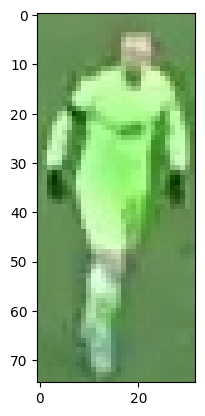

In [15]:
plt.imshow(image)
plt.show()

# Taking the top half of the image for the T-shirt

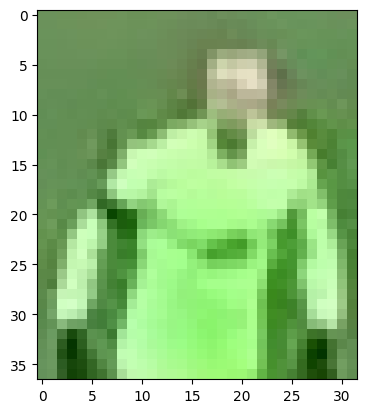

In [16]:
topHalfImage = image[0: int(image.shape[0]/2), :]
plt.imshow(topHalfImage)
plt.show()

# Cluster the image into two sub-clusters

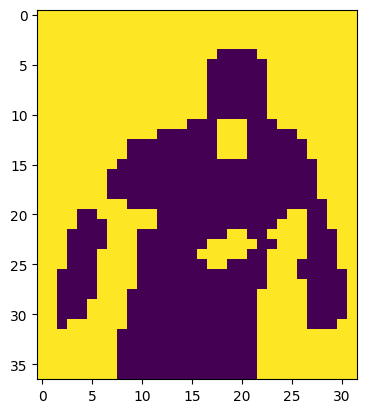

In [ ]:
# Reshape the image into 2D array from (height, width, channels) to (height * width, channels)
image2D = image.reshape(-1, 3)

# Perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=41)
kmeans.fit(image2D)

# Get the cluster labels
labels = kmeans.labels_

# Reshape the labels into the image shape
clusteredImage = labels.reshape(image.shape[0], image.shape[1])[0: int(image.shape[0]/2), :]

plt.imshow(clusteredImage)
plt.show()

In [ ]:
cornerClusters = [clusteredImage[0, 0], clusteredImage[0, -1], clusteredImage[-1, 0], clusteredImage[-1, -1]]
nonPlayerCluster = max(set(cornerClusters), key=cornerClusters.count)
playerCluster = 1 - nonPlayerCluster

print(playerCluster)

0


In [ ]:
kmeans.cluster_centers_[player_cluster]